# Problema 7

**Solución numérica de ecuaciones diferenciales**.

Use el **método de Leapfrog** para encontrar la solución numérica de las siguientes ecuaciones diferenciales, partiendo de las condiciones iniciales provistas. En cada caso haga un **gráfico de la solución** en un intervalo adecuadamente escogido.

*   **a)** $\frac{d^{2}x}{dt^{2}} = -\frac{x}{t^{2}}$, con $x(1) = 1$ y $\dot{x}(1) = 0$.
*   **b)** $\ddot{x} - 2\dot{x} + 2x = 0$, con $x(0) = 1$ y $\dot{x}(0) = 0$.

## Reduccion de orden de cada sistema

Para aplicar Leap-frog, escribimos cada EDO de segundo orden como un sistema de primer orden usando:
$$
v = \dot{x}.
$$

### a) $\ddot{x} = -\frac{x}{t^2}$, con $x(1)=1$, $\dot{x}(1)=0$

Definimos $$v=\dot{x}$$. Entonces:
$$
\begin{cases}
\dot{x} = v, \\
\dot{v} = -\dfrac{x}{t^2}.
\end{cases}
$$
Condiciones iniciales:
$$
x(1)=1, \qquad v(1)=0.
$$

### b) $$\ddot{x} $$2\dot{x} + 2x = 0\), con $$x(0)=1\),$$$\dot{x}(0$$0\)

Reordenando:
$$
\ddot{x} = 2\dot{x} - 2x.
$$
Con $$v=\dot{x}$$:
$$
\begin{cases}
\dot{x} = v, \\
\dot{v} = 2v - 2x.
\end{cases}
$$
Condiciones iniciales:
$$
x(0)=1, \qquad v(0)=0.
$$

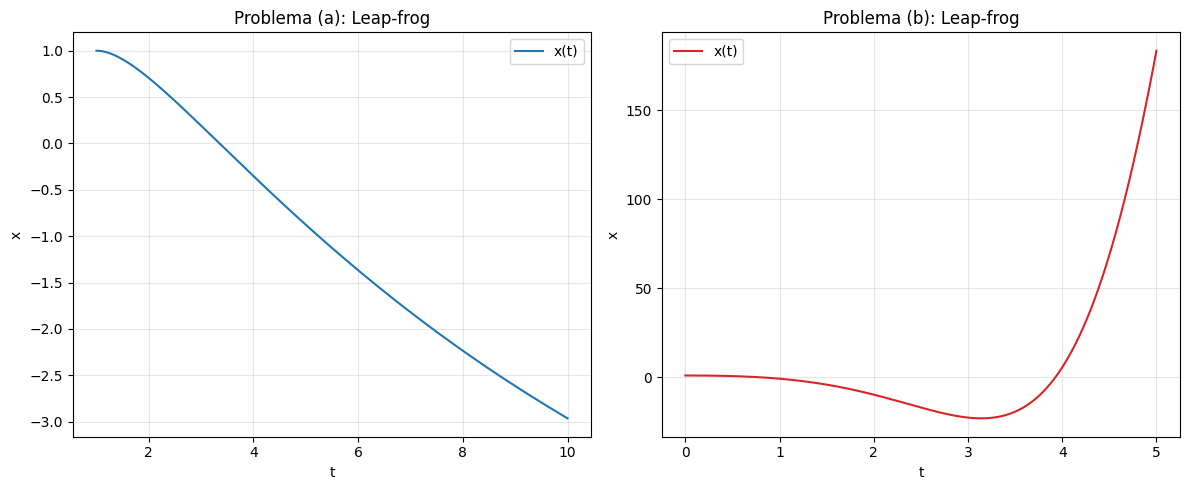

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def leapfrog_second_order(accel, t0, x0, v0, h, n_steps):
    t = np.empty(n_steps + 1)
    x = np.empty(n_steps + 1)
    v = np.empty(n_steps + 1)

    t[0] = t0
    x[0] = x0
    v[0] = v0

    # Velocidad en medio paso (kick inicial)
    v_half = v0 + 0.5 * h * accel(t0, x0, v0)

    for n in range(n_steps):
        t[n + 1] = t[n] + h

        # Drift
        x[n + 1] = x[n] + h * v_half

        # Kick
        v_half = v_half + h * accel(t[n + 1], x[n + 1], v_half)

        # Reconstruccion de v en paso entero
        v[n + 1] = v_half - 0.5 * h * accel(t[n + 1], x[n + 1], v_half)

    return t, x, v


# Problema (a): x'' = -x / t^2, x(1)=1, x'(1)=0
def accel_a(t, x, v):
    return -x / (t**2)

h_a = 0.01
t0_a, tf_a = 1.0, 10.0
n_a = int((tf_a - t0_a) / h_a)
t_a, x_a, v_a = leapfrog_second_order(accel_a, t0_a, 1.0, 0.0, h_a, n_a)


# Problema (b): x'' - 2x' + 2x = 0 => x'' = 2x' - 2x, x(0)=1, x'(0)=0
def accel_b(t, x, v):
    return 2.0 * v - 2.0 * x

h_b = 0.001
t0_b, tf_b = 0.0, 5.0
n_b = int((tf_b - t0_b) / h_b)
t_b, x_b, v_b = leapfrog_second_order(accel_b, t0_b, 1.0, 0.0, h_b, n_b)


# Graficos
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_a, x_a, color='tab:blue', label='x(t)')
plt.title('Problema (a): Leap-frog')
plt.xlabel('t')
plt.ylabel('x')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t_b, x_b, color='tab:red', label='x(t)')
plt.title('Problema (b): Leap-frog')
plt.xlabel('t')
plt.ylabel('x')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()